In [1]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if len(root.split(os.sep)) > 7:  # stop after 4 levels deep
        break

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ani3hhh
/kaggle/input/datasets/ani3hhh/vr-dataset
/kaggle/input/datasets/ani3hhh/vr-dataset/data
/kaggle/input/datasets/ani3hhh/vr-dataset/data/json_for_validation


In [2]:
import json, os

sample_ann = "/kaggle/input/datasets/ani3hhh/vr-dataset/data/train/annos"
f = os.listdir(sample_ann)[0]
with open(os.path.join(sample_ann, f)) as fp:
    d = json.load(fp)

print(type(d))
print(list(d.keys())[:5])
# peek at first value
first_key = list(d.keys())[0]
print(d[first_key])

<class 'dict'>
['item2', 'source', 'pair_id', 'item1']
{'segmentation': [[360, 172, 364, 166, 371, 163, 325, 168, 299, 202, 279, 234, 258, 263, 233, 299, 256, 311, 273, 273, 288, 246, 304, 223, 308, 203, 298, 211, 279, 239, 258, 269, 287, 292, 306, 242, 341, 213, 360, 172], [410, 182, 409, 188, 406, 194, 383, 230, 380, 277, 366, 323, 402, 330, 414, 291, 424, 250, 424, 240, 418, 269, 409, 299, 397, 336, 385, 367, 418, 375, 422, 340, 428, 307, 435, 261, 433, 197, 410, 182], [325, 168, 299, 202, 279, 234, 258, 263, 233, 299, 256, 311, 273, 273, 288, 246, 304, 223, 308, 203, 325, 168], [424, 240, 418, 269, 409, 299, 397, 336, 385, 367, 418, 375, 422, 340, 428, 307, 435, 261, 433, 197, 424, 240], [279, 234, 258, 263, 233, 299, 256, 311, 273, 273, 288, 246, 279, 234], [409, 299, 397, 336, 385, 367, 418, 375, 422, 340, 428, 307, 409, 299]], 'scale': 2, 'viewpoint': 2, 'zoom_in': 1, 'landmarks': [387, 176, 1, 371, 163, 1, 364, 166, 1, 360, 172, 2, 409, 188, 2, 410, 182, 2, 325, 168, 1, 299, 20

In [3]:
import os
import json
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
import os
import json
import random
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split

BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"   # adjust slug if needed

TRAIN_IMAGE_DIR = f"{BASE}/train/image"
TRAIN_ANN_DIR   = f"{BASE}/train/annos"

VAL_IMAGE_DIR   = f"{BASE}/validation/image"
VAL_ANN_DIR     = f"{BASE}/validation/annos"

TEST_IMAGE_DIR  = f"{BASE}/test/test"
TEST_ANN_DIR    = f"{BASE}/json_for_validation"   # only annotations available for test

DATA_SPLITS = [
    (TRAIN_IMAGE_DIR, TRAIN_ANN_DIR),
    (VAL_IMAGE_DIR,   VAL_ANN_DIR),
    (TEST_IMAGE_DIR,  TEST_ANN_DIR),
]

OUTPUT_DIR = "/kaggle/working/processed_dataset"
TARGET_RATIO = 0.6

random.seed(42)

# Count category frequencies
category_counter = Counter()
image_to_categories = {}
category_id_to_name = {}


from concurrent.futures import ThreadPoolExecutor
print("Scanning dataset annotations...")

def process_annotation(args):

    IMAGE_DIR, ANN_DIR, ann_file = args

    if not ann_file.endswith(".json"):
        return None

    ann_path = os.path.join(ANN_DIR, ann_file)

    try:
        with open(ann_path) as f:
            data = json.load(f)
    except:
        return None

    if not isinstance(data, dict):
        return None

    cats = set()
    local_names = {}

    for key, val in data.items():

        if key.startswith("item") and isinstance(val, dict) and "category_id" in val:

            cat = val["category_id"]
            cats.add(cat)

            if "category_name" in val:
                local_names[cat] = val["category_name"]

    if len(cats) == 0:
        return None

    image_name = ann_file.replace(".json", ".jpg")
    image_path = os.path.abspath(os.path.join(IMAGE_DIR, image_name))

    if not os.path.exists(image_path):
        return None

    return image_path, cats, local_names

tasks = []

for IMAGE_DIR, ANN_DIR in DATA_SPLITS:
    for ann_file in os.listdir(ANN_DIR):
        tasks.append((IMAGE_DIR, ANN_DIR, ann_file))

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_annotation, tasks))

for r in results:

    if r is None:
        continue

    image_path, cats, local_names = r

    image_to_categories[image_path] = list(cats)

    for c in cats:
        category_counter[c] += 1

    category_id_to_name.update(local_names)


print("\nCategory frequencies:")
print(category_counter)

# Select top 5 categories
top5 = [c for c, _ in category_counter.most_common(5)]

print("\nTop 5 categories:", top5)

label_map = {cat: i for i, cat in enumerate(top5)}
NUM_CLASSES = len(top5)

# Filter images containing top-5 classes
filtered_images = []

for img, cats in image_to_categories.items():

    filtered = [c for c in cats if c in top5]

    if len(filtered) > 0:
        filtered_images.append((img, filtered))


print("\nImages after filtering:", len(filtered_images))

# Create multi-label vectors
dataset = []

for img, cats in filtered_images:

    label_vector = [0] * NUM_CLASSES

    for c in cats:
        label_vector[label_map[c]] = 1

    dataset.append({
        "image": img,
        "labels": label_vector
    })


print("Dataset entries created:", len(dataset))

# Balanced subset sampling
target_size = int(len(dataset) * TARGET_RATIO)

print("\nCreating balanced subset:", target_size)

class_buckets = defaultdict(list)

for sample in dataset:

    for idx, val in enumerate(sample["labels"]):

        if val == 1:
            class_buckets[idx].append(sample)


subset = []
seen = set()

target_per_class = target_size // NUM_CLASSES

for cls in range(NUM_CLASSES):

    candidates = class_buckets[cls]
    random.shuffle(candidates)

    selected = 0

    for sample in candidates:

        if sample["image"] in seen:
            continue

        subset.append(sample)
        seen.add(sample["image"])
        selected += 1

        if selected >= target_per_class:
            break

print("Subset size:", len(subset))

# Train / Validation / Test split
images = [s["image"] for s in subset]
labels = [s["labels"] for s in subset]

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42
)

val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print("\nSplit sizes:")
print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

# Save splits
os.makedirs(OUTPUT_DIR, exist_ok=True)

splits = {
    "train": (train_imgs, train_labels),
    "val": (val_imgs, val_labels),
    "test": (test_imgs, test_labels)
}

for split in splits:

    imgs, lbls = splits[split]

    data = []

    for img, lbl in zip(imgs, lbls):

        data.append({
            "image": os.path.relpath(img, start=BASE),
            "labels": lbl
        })

    out_path = os.path.join(OUTPUT_DIR, f"{split}.json")

    with open(out_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"{split} file saved → {out_path}")


print("\nPreprocessing completed successfully.")

# Save label_map so preprocessing_detection.py can read the exact same top-5
# Create required format: class_name -> index
# Required class order from assignment
label_map_json = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

print("\nFinal Label Mapping (class_name -> index):")
for name, idx in label_map_json.items():
    print(f"{name} : {idx}")

# Save label_map.json
with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump(label_map_json, f, indent=4)

print("\nlabel_map.json saved in required format.")

Scanning dataset annotations...

Category frequencies:
Counter({1: 82957, 8: 64463, 2: 41667, 7: 40465, 9: 37124, 12: 21086, 10: 20104, 5: 18072, 4: 15380, 11: 9263, 13: 7592, 6: 2281, 3: 681})

Top 5 categories: [1, 8, 2, 7, 9]

Images after filtering: 167915
Dataset entries created: 167915

Creating balanced subset: 100749
Subset size: 100745

Split sizes:
Train: 70521
Validation: 15112
Test: 15112
train file saved → /kaggle/working/processed_dataset/train.json
val file saved → /kaggle/working/processed_dataset/val.json
test file saved → /kaggle/working/processed_dataset/test.json

Preprocessing completed successfully.

Final Label Mapping (class_name -> index):
short sleeve top : 0
trousers : 1
shorts : 2
long sleeve top : 3
skirt : 4

label_map.json saved in required format.


In [5]:
BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"
class MultiLabelDataset(Dataset):
    """
    Reads from the JSON split files produced by preprocessing.py.
    Each entry has:
        { "image": "<path>", "labels": [0, 1, 0, 1, 0] }
    """
    def __init__(self, split_json, transform=None):
        with open(split_json) as f:
            self.data = json.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        entry = self.data[idx]
        img_path = os.path.join(BASE, entry["image"])
        image = Image.open(img_path).convert("RGB")
        label_vector = torch.tensor(entry["labels"], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label_vector

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [7]:
PROCESSED_DIR = "processed_dataset"
NUM_CLASSES = 5

train_dataset = MultiLabelDataset(
    os.path.join(PROCESSED_DIR, "train.json"),
    transform=train_transform
)

val_dataset = MultiLabelDataset(
    os.path.join(PROCESSED_DIR, "val.json"),
    transform=val_transform
)

test_dataset = MultiLabelDataset(
    os.path.join(PROCESSED_DIR, "test.json"),
    transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 70521 | Val: 15112 | Test: 15112


In [8]:
BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"
sample = train_dataset.data[0]
full_path = os.path.join(BASE, sample["image"])
print(full_path)
print(os.path.exists(full_path))  # must print True

/kaggle/input/datasets/ani3hhh/vr-dataset/data/train/image/151581.jpg
True


In [9]:
def evaluate(model, loader, tag=""):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            all_probs.append(probs)
            all_preds.append(preds)
            all_labels.append(labels.numpy())

    all_probs  = np.vstack(all_probs)
    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
    recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
    f1_per    = f1_score(all_labels, all_preds, average=None, zero_division=0)
    f1_macro  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    f1_micro  = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    auc       = roc_auc_score(all_labels, all_probs, average=None)

    print(f"\n=== {tag} ===")
    print(f"{'Class':<8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
    for i in range(NUM_CLASSES):
        print(f"  [{i}]   {precision[i]:>10.4f} {recall[i]:>8.4f} {f1_per[i]:>8.4f} {auc[i]:>8.4f}")
    print(f"Macro F1 : {f1_macro:.4f}")
    print(f"Micro F1 : {f1_micro:.4f}")

    return all_probs, all_preds, all_labels


def plot_roc_curves(all_labels, all_probs, tag=""):
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        auc_val = roc_auc_score(all_labels[:, i], all_probs[:, i])
        axes[i].plot(fpr, tpr, label=f"AUC={auc_val:.3f}")
        axes[i].plot([0, 1], [0, 1], "k--")
        axes[i].set_title(f"Class {i}")
        axes[i].set_xlabel("FPR")
        axes[i].set_ylabel("TPR")
        axes[i].legend()
    fig.suptitle(f"ROC Curves — {tag}")
    plt.tight_layout()
    plt.savefig(f"roc_{tag.lower().replace(' ', '_')}.png", dpi=120)
    plt.show()


def tune_thresholds(all_labels, all_probs):
    thresholds = np.arange(0.1, 0.91, 0.05)
    best_thresholds, best_f1s = [], []
    for i in range(NUM_CLASSES):
        best_f1, best_t = 0, 0.5
        for t in thresholds:
            preds = (all_probs[:, i] > t).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(best_t)
        best_f1s.append(best_f1)
    print("Best thresholds per class:", best_thresholds)
    print("Best F1 per class:        ", best_f1s)
    return best_thresholds


def evaluate_tuned(all_labels, all_probs, best_thresholds, tag=""):
    tuned_preds = np.zeros_like(all_probs, dtype=int)
    for i in range(NUM_CLASSES):
        tuned_preds[:, i] = (all_probs[:, i] > best_thresholds[i]).astype(int)
    f1_macro = f1_score(all_labels, tuned_preds, average="macro", zero_division=0)
    f1_micro = f1_score(all_labels, tuned_preds, average="micro", zero_division=0)
    print(f"\n=== {tag} — After Threshold Tuning ===")
    print(f"Precision : {precision_score(all_labels, tuned_preds, average=None, zero_division=0)}")
    print(f"Recall    : {recall_score(all_labels, tuned_preds, average=None, zero_division=0)}")
    print(f"Macro F1  : {f1_macro:.4f}")
    print(f"Micro F1  : {f1_micro:.4f}")

In [10]:
scratch_model = torchvision.models.mobilenet_v3_large(weights=None)
scratch_model.classifier[3] = torch.nn.Linear(
    scratch_model.classifier[3].in_features, NUM_CLASSES
)
scratch_model.to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(scratch_model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

In [11]:
import os
print(os.listdir("/kaggle/input/datasets/ani3hhh/vr-dataset/data"))

['json_for_validation', 'validation', 'label_map_classification.json', 'top5.json', 'test', 'train']


In [12]:
num_epochs = 10

for epoch in range(num_epochs):
    scratch_model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = scratch_model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    print(f"[Scratch] Epoch {epoch+1}/{num_epochs}  Loss: {total_loss:.4f}  LR: {scheduler.get_last_lr()[0]:.2e}")

[Scratch] Epoch 1/10  Loss: 1326.4078  LR: 1.00e-04
[Scratch] Epoch 2/10  Loss: 1216.1160  LR: 1.00e-04
[Scratch] Epoch 3/10  Loss: 1130.9517  LR: 5.00e-05
[Scratch] Epoch 4/10  Loss: 1051.9330  LR: 5.00e-05
[Scratch] Epoch 5/10  Loss: 1009.5578  LR: 5.00e-05
[Scratch] Epoch 6/10  Loss: 970.4014  LR: 2.50e-05
[Scratch] Epoch 7/10  Loss: 923.7412  LR: 2.50e-05
[Scratch] Epoch 8/10  Loss: 901.1581  LR: 2.50e-05
[Scratch] Epoch 9/10  Loss: 879.6467  LR: 1.25e-05
[Scratch] Epoch 10/10  Loss: 851.7570  LR: 1.25e-05



=== Scratch — Validation ===
Class     Precision   Recall       F1      AUC
  [0]       0.6985   0.6593   0.6783   0.7900
  [1]       0.8426   0.7635   0.8011   0.9368
  [2]       0.6676   0.5059   0.5756   0.8128
  [3]       0.7610   0.6292   0.6889   0.8869
  [4]       0.6650   0.5503   0.6022   0.8333
Macro F1 : 0.6692
Micro F1 : 0.6743


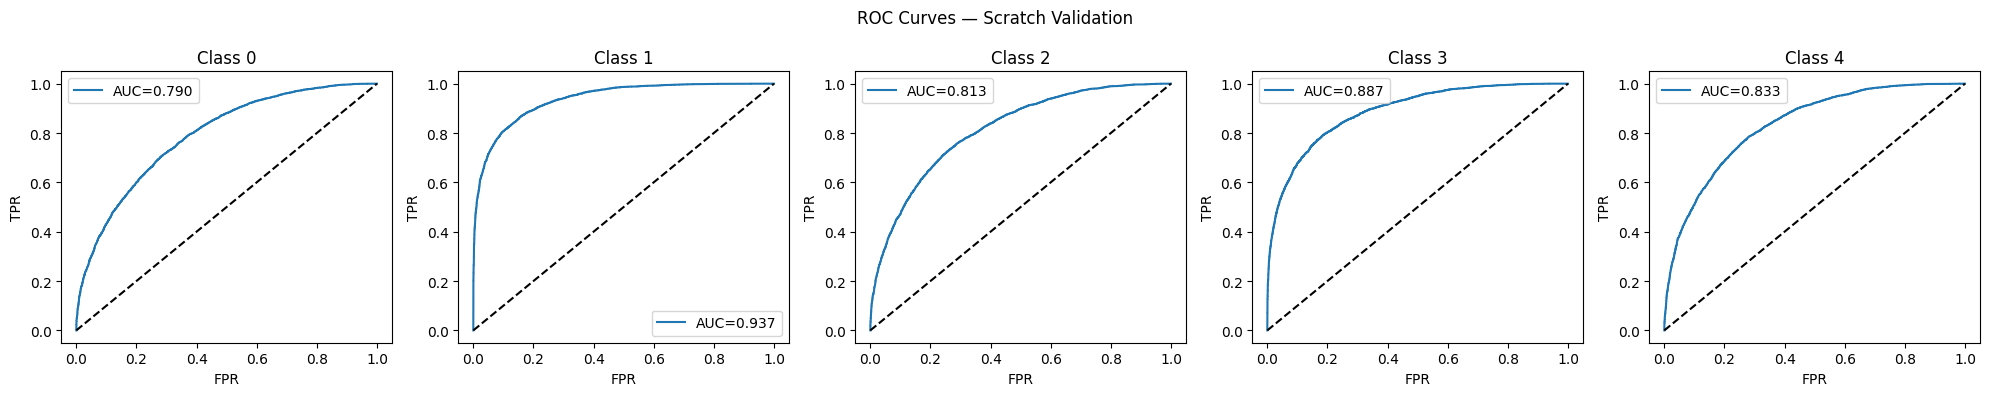

In [13]:
scratch_probs, scratch_preds, scratch_labels = evaluate(scratch_model, val_loader, tag="Scratch — Validation")
plot_roc_curves(scratch_labels, scratch_probs, tag="Scratch Validation")

In [14]:
scratch_thresholds = tune_thresholds(scratch_labels, scratch_probs)
evaluate_tuned(scratch_labels, scratch_probs, scratch_thresholds, tag="Scratch")

Best thresholds per class: [np.float64(0.30000000000000004), np.float64(0.40000000000000013), np.float64(0.30000000000000004), np.float64(0.40000000000000013), np.float64(0.30000000000000004)]
Best F1 per class:         [0.7173388283779806, 0.8058881256133464, 0.6306126158880203, 0.706317981948623, 0.6400150503245227]

=== Scratch — After Threshold Tuning ===
Precision : [0.6111557  0.80525593 0.54880557 0.7124183  0.55272136]
Recall    : [0.86817728 0.80652131 0.74108097 0.70032125 0.76005362]
Macro F1  : 0.7000
Micro F1  : 0.7005


In [15]:
torch.save(scratch_model.state_dict(), "mobilenet_v3_scratch.pth")
print("Saved: mobilenet_v3_scratch.pth")

Saved: mobilenet_v3_scratch.pth


In [16]:
transfer_model = torchvision.models.mobilenet_v3_large(weights="DEFAULT")

# Freeze all backbone layers
for param in transfer_model.parameters():
    param.requires_grad = False

# Replace classifier head and unfreeze it
transfer_model.classifier[3] = torch.nn.Linear(
    transfer_model.classifier[3].in_features, NUM_CLASSES
)
for param in transfer_model.classifier[3].parameters():
    param.requires_grad = True

transfer_model.to(device)

criterion_tl = torch.nn.BCEWithLogitsLoss()
optimizer_tl = torch.optim.Adam(transfer_model.classifier[3].parameters(), lr=1e-3)
scheduler_tl = torch.optim.lr_scheduler.StepLR(optimizer_tl, step_size=3, gamma=0.5)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 180MB/s]


In [17]:
# Phase 1 — train head only
num_epochs_phase1 = 5

for epoch in range(num_epochs_phase1):
    transfer_model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = transfer_model(images)
        loss = criterion_tl(outputs, labels)
        optimizer_tl.zero_grad()
        loss.backward()
        optimizer_tl.step()
        total_loss += loss.item()

    scheduler_tl.step()
    print(f"[Transfer Phase-1] Epoch {epoch+1}/{num_epochs_phase1}  Loss: {total_loss:.4f}")

# Phase 2 — unfreeze last two feature blocks for fine-tuning
print("\nUnfreezing last two feature blocks for fine-tuning...")
for name, param in transfer_model.named_parameters():
    if "features.15" in name or "features.16" in name or "classifier" in name:
        param.requires_grad = True

optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, transfer_model.parameters()),
    lr=1e-4
)
scheduler_ft = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=3, gamma=0.5)


num_epochs_phase2 = 5

for epoch in range(num_epochs_phase2):
    transfer_model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = transfer_model(images)
        loss = criterion_tl(outputs, labels)
        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
        total_loss += loss.item()

    scheduler_ft.step()
    print(f"[Transfer Phase-2] Epoch {epoch+1}/{num_epochs_phase2}  Loss: {total_loss:.4f}")

[Transfer Phase-1] Epoch 1/5  Loss: 1126.1188
[Transfer Phase-1] Epoch 2/5  Loss: 1093.5730
[Transfer Phase-1] Epoch 3/5  Loss: 1089.0841
[Transfer Phase-1] Epoch 4/5  Loss: 1082.4603
[Transfer Phase-1] Epoch 5/5  Loss: 1081.5733

Unfreezing last two feature blocks for fine-tuning...
[Transfer Phase-2] Epoch 1/5  Loss: 955.3663
[Transfer Phase-2] Epoch 2/5  Loss: 824.2477
[Transfer Phase-2] Epoch 3/5  Loss: 741.6570
[Transfer Phase-2] Epoch 4/5  Loss: 664.0044
[Transfer Phase-2] Epoch 5/5  Loss: 627.6653



=== Transfer — Validation ===
Class     Precision   Recall       F1      AUC
  [0]       0.7907   0.7423   0.7657   0.8771
  [1]       0.8798   0.8711   0.8754   0.9698
  [2]       0.7435   0.6984   0.7202   0.8983
  [3]       0.8569   0.7462   0.7977   0.9454
  [4]       0.7837   0.7084   0.7442   0.9189
Macro F1 : 0.7807
Micro F1 : 0.7814


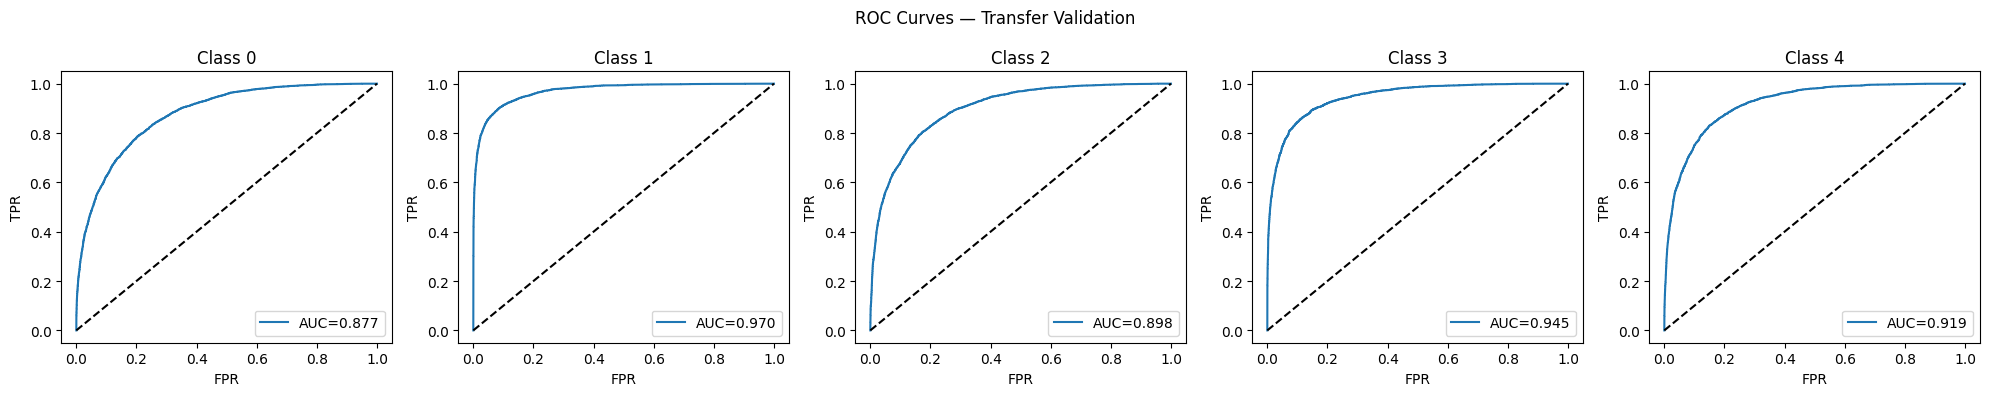

In [18]:
transfer_probs, transfer_preds, transfer_labels = evaluate(transfer_model, val_loader, tag="Transfer — Validation")
plot_roc_curves(transfer_labels, transfer_probs, tag="Transfer Validation")

In [19]:
transfer_thresholds = tune_thresholds(transfer_labels, transfer_probs)
evaluate_tuned(transfer_labels, transfer_probs, transfer_thresholds, tag="Transfer")

Best thresholds per class: [np.float64(0.3500000000000001), np.float64(0.5500000000000002), np.float64(0.3500000000000001), np.float64(0.3500000000000001), np.float64(0.3500000000000001)]
Best F1 per class:         [0.7843836702338486, 0.8769215311966241, 0.734073641145529, 0.8097924187725631, 0.7589787053713317]

=== Transfer — After Threshold Tuning ===
Precision : [0.7310676  0.89757302 0.67466428 0.79649356 0.72174088]
Recall    : [0.84608807 0.85719898 0.80495621 0.82354291 0.8002681 ]
Macro F1  : 0.7928
Micro F1  : 0.7917


In [20]:
torch.save(transfer_model.state_dict(), "mobilenet_v3_transfer.pth")
print("Saved: mobilenet_v3_transfer.pth")

Saved: mobilenet_v3_transfer.pth



=== Transfer — Test Set ===
Class     Precision   Recall       F1      AUC
  [0]       0.7917   0.7439   0.7671   0.8774
  [1]       0.8988   0.8640   0.8811   0.9694
  [2]       0.7641   0.7080   0.7350   0.9016
  [3]       0.8490   0.7478   0.7952   0.9441
  [4]       0.7845   0.7201   0.7509   0.9202
Macro F1 : 0.7859
Micro F1 : 0.7864


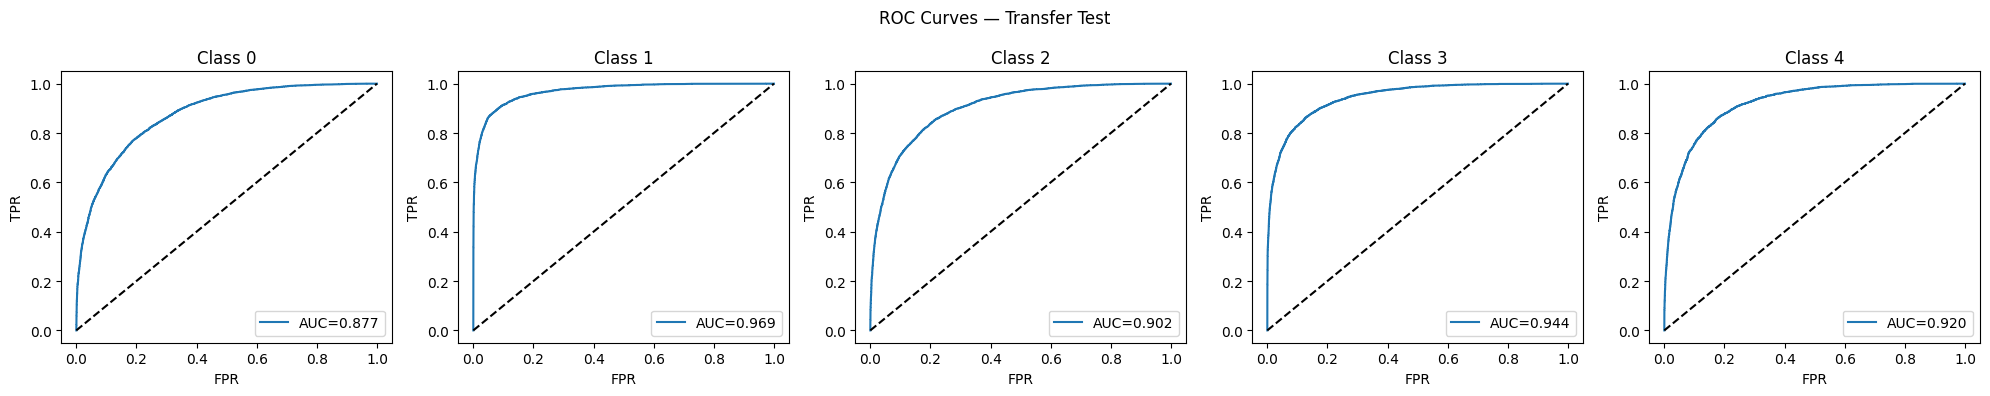


=== Transfer Test — After Threshold Tuning ===
Precision : [0.72604423 0.90750726 0.68038088 0.79012619 0.71311475]
Recall    : [0.84356266 0.85003885 0.80660277 0.81391106 0.80902699]
Macro F1  : 0.7913
Micro F1  : 0.7901


In [21]:
# Evaluate best model (transfer) on held-out test set
test_probs, test_preds, test_labels = evaluate(transfer_model, test_loader, tag="Transfer — Test Set")
plot_roc_curves(test_labels, test_probs, tag="Transfer Test")
evaluate_tuned(test_labels, test_probs, transfer_thresholds, tag="Transfer Test")